# Block-specific selection beyond ecotype winnowing — linear-scale LD-LMM (site 4)

We ask, per haploblock, whether its allele rose **more than linkage to the winning founder
genomes predicts** — i.e. block-specific (convergent) selection *on top of* the genome-wide
ecotype winnowing, under near-complete selfing where whole ecotype genomes segregate as units.

This is the **corrected** model. An earlier logit-scale version produced a frequency-dependent
**sign artifact** (rare haplotypes pushed to spurious negative residuals, near-fixed to positive),
because the response was on the logit scale while the founder control $\mathbf C_{LD}$ is linear
in founder indicators ($\mathrm{logit}(\sum h_f)\neq\sum(\cdots)$). Here everything is on the
**linear (raw-frequency) scale**, where the projection is exact and the residual sign is meaningful.

## The model

**Response (linear, temporal, replicated).** Per block $b$, per replicate plot $j$: the OLS slope
$\beta_{b,j}$ of the **raw** haplotype frequency $f$ over generations $t=0,1,2,3$; then
$s_b=\frac1n\sum_j\beta_{b,j}$ (block-level $\Delta p$ rate), with replicate error $\mathrm{SE}_b$.

**What we control — $\mathbf C_{LD}$ (linkage = founder-sharing).** Because $f_b=\sum_{f\in b}h_f$,
$\Delta f_b=\sum_{f\in b}\Delta h_f$ is **exactly linear** in the founder changes. So the founder
relationship matrix $\mathbf C_{LD}=\tfrac1{n_F}\mathbf A^\top\mathbf A$ ($A$ = founder-standardized
haplotype indicators) can **fully absorb** the clade-wide winning (hitchhiking + "winners are one
clade"), with **no logit-curvature artifact**.

**Measurement variance $D_b$ (sampling floor).** The replicate $\mathrm{SE}_b$ *collapses* for
rare/near-fixed haplotypes (median $\mathrm{SE}^2/$floor $\approx0.5$ → spurious huge $z$), so we
floor it at the flower-census **binomial** variance $\mathrm{Var}(f)=f(1-f)/N_{\text{gam}}$:
$$D_b=\Big(\tfrac{c_0}{5}\Big)^2 v^{(0)}_b+\max\!\Big(\mathrm{SE}_b^2,\ \tfrac1{n^2}\textstyle\sum_j\sum_{t\ge1}\big(\tfrac{c_t}{5}\big)^2\tfrac{f_{t,j}(1-f_{t,j})}{N_{\text{gam}}}\Big).$$

**Fit & test.** $s_b=\mu+g_b+\varepsilon_b$, $\mathbf g\sim\mathcal N(0,\sigma_g^2\mathbf C_{LD})$,
$\varepsilon_b\sim\mathcal N(0,\sigma_e^2+D_b)$, REML (Woodbury, low-rank). The block-specific
residual $r_b=s_b-\hat g_b$ now has a **meaningful sign**: $r_b>0$ = rose **more** than founder
linkage predicts (the **target**); $z_b=r_b/\sqrt{\sigma_e^2+D_b}$.

**Threshold — selfing-aware drift-projection null.** The parametric $p$ is deflated; we set the
genome-wide threshold by a **generative** null: simulate the founder frequencies under Wright–Fisher
drift (pooled $N_e$ fit to the among-plot variance — absorbs selfing's drift inflation; here
$N_e\!\approx\!64$) $+$ flower-census sampling around the real winning trajectory, then **project**
through the founder$\to$haplotype membership (so every block is a pure founder projection $=H_0$, and
whole-genome/selfing sampling reproduces the correlated cross-block noise). Run the identical pipeline
(REML-refit per sim) → the **one-sided** maxT (95th pct of $\max_b z_b$ over the boundary-guarded
$panel\_freq\in[0.10,0.90]$ set) is the rose-more FWER 5% line.

## Load the model + drift-null calibration

In [1]:
import os, json
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
H = "results/grenenet_gea/hapfreq"; SITE = 4
CHROMS = ["Chr1","Chr2","Chr3","Chr4","Chr5"]

In [2]:
# --- estimator (effects) joined to the drift-null (calibration) on the UNIQUE haplotype id gid ---
# (units hold up to k-1 testable haplotypes -> chrom:start-end is NOT unique; gid is.)
mod  = pd.read_csv(f"{H}/site{SITE}_block_ld_lmm_linear_sampvar.csv")          # gid,s,linked_bg,resid,z,p_pos,q_pos
modm = json.load(open(f"{H}/site{SITE}_block_ld_lmm_linear_sampvar_meta.json"))
dn   = pd.read_csv(f"{H}/site{SITE}_block_ld_lmm_driftnull_linear.csv")        # gid,guard,p_pos_marg,p_pos_fwer,q_pos_drift
dnm  = json.load(open(f"{H}/site{SITE}_block_ld_lmm_driftnull_linear_meta.json"))
d = mod.merge(dn[["gid","guard","p_pos_marg","p_pos_fwer","q_pos_drift"]], on="gid", how="left")
print(f"site {SITE}: {len(d):,} testable haploblock-haplotypes; {int(d.guard.sum()):,} in target band [0.10,0.90]")
print(f"  h2(linkage)={modm['h2']:.2f}   parametric lambda_GC={modm['lambda_gc']:.2f} (deflated -> drift null is the threshold)")
print(f"  pooled Ne (selfing-aware)={dnm['Ne']:.0f}, {dnm['NSIM']} drift-projection sims")

site 4: 26,243 testable haploblock-haplotypes; 18,931 in target band [0.10,0.90]
  h2(linkage)=0.96   parametric lambda_GC=0.84 (deflated -> drift null is the threshold)
  pooled Ne (selfing-aware)=64, 2000 drift-projection sims


## Genome-wide significant: blocks that rose MORE than ecotype winnowing

In [3]:
# --- headline: genome-wide rose-MORE-than-ecotype blocks (drift-null FWER) ---
thr = float(dnm["rose_more_maxT_fwer05"])
print(f"rose-MORE one-sided maxT FWER 5% threshold:  z > {thr:.2f}   (obs max guarded z = {dnm['obs_max_z_guarded']:.2f})")
sig = d[(d.guard==True) & (d.p_pos_fwer<0.05)].sort_values("p_pos_fwer")
nbh = int((d.guard & (d.q_pos_drift<0.05)).sum())
print(f"genome-wide FWER-significant: {len(sig)}   |   drift-BH q<0.05: {nbh}")
print("\n  (s>0 rose, linked_bg~0 = decoupled from the winning clade, resid>0 = rose MORE than predicted)")
sig[["chrom","unit_start","unit_end","panel_freq","s","linked_bg","resid","z","p_pos_fwer","q_pos_drift"]]

rose-MORE one-sided maxT FWER 5% threshold:  z > 4.21   (obs max guarded z = 5.18)
genome-wide FWER-significant: 4   |   drift-BH q<0.05: 11

  (s>0 rose, linked_bg~0 = decoupled from the winning clade, resid>0 = rose MORE than predicted)


,chrom,unit_start,unit_end,panel_freq,s,linked_bg,resid,z,p_pos_fwer,q_pos_drift
33,Chr2,13770439,13775598,0.14719,0.078353,0.011915,0.076351,5.181916,0.000500,0.012325
68,Chr2,13725657,13732568,0.10823,0.077794,0.014692,0.073015,4.531922,0.003498,0.012325
66,Chr2,13722496,13725256,0.22944,0.068622,-0.004002,0.082538,4.535148,0.003998,0.012325
75,Chr2,13767308,13770264,0.10823,0.093148,0.035660,0.067401,4.455814,0.003998,0.012325


## Manhattan — signed block-specific residual

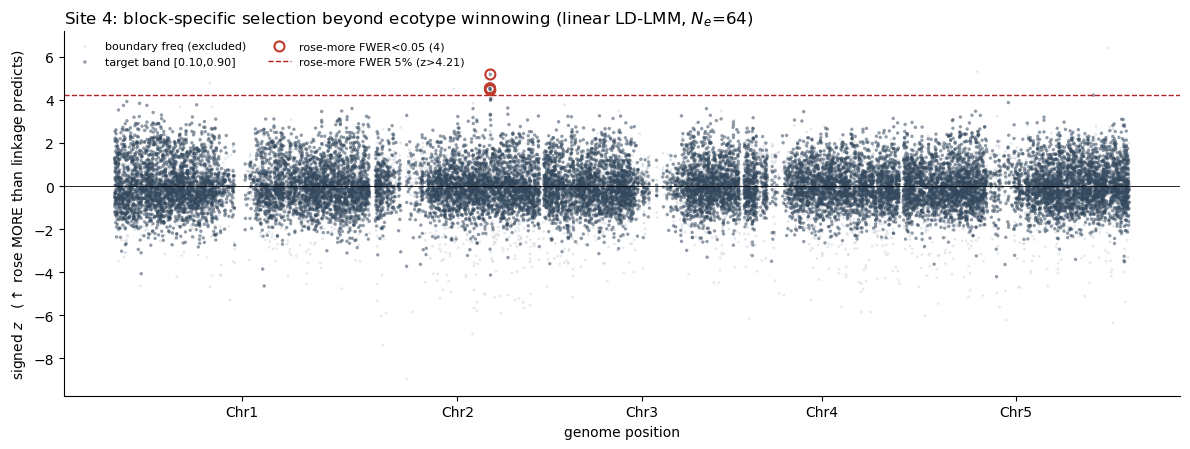

In [4]:
# --- Manhattan: signed z, rose-MORE emphasis, one-sided drift-null FWER line ---
g2 = d.copy(); g2["mid"]=(g2.unit_start+g2.unit_end)/2
g2 = g2.sort_values(["chrom","unit_start"]).reset_index(drop=True)
off, centers, x = 0.0, [], np.zeros(len(g2))
for ch in CHROMS:
    mk=(g2.chrom==ch).to_numpy()
    if not mk.any(): continue
    x[mk]=g2.mid[mk]+off; centers.append(off+g2.mid[mk].max()/2); off+=g2.mid[mk].max()*1.02
g2["x"]=x
fig, ax = plt.subplots(figsize=(12,4.6))
bnd = ~g2.guard.fillna(False).to_numpy()
ax.scatter(g2.x[bnd], g2.z[bnd], s=4, c="#c9ccd6", alpha=.45, edgecolors="none", rasterized=True,
           label="boundary freq (excluded)")
gu = g2.guard.fillna(False).to_numpy()
ax.scatter(g2.x[gu], g2.z[gu], s=6, c="#34495e", alpha=.55, edgecolors="none", rasterized=True,
           label="target band [0.10,0.90]")
sv=(g2.guard==True)&(g2.p_pos_fwer<0.05)
ax.scatter(g2.x[sv], g2.z[sv], s=52, facecolors="none", edgecolors="#c0392b", lw=1.5,
           label=f"rose-more FWER<0.05 ({int(sv.sum())})", zorder=5)
ax.axhline(0, color="k", lw=.6)
ax.axhline(thr, color="firebrick", lw=1, ls="--", label=f"rose-more FWER 5% (z>{thr:.2f})")
ax.set_xticks(centers); ax.set_xticklabels(CHROMS)
ax.set_ylabel(r"signed $z$   ($\uparrow$ rose MORE than linkage predicts)"); ax.set_xlabel("genome position")
ax.set_title(f"Site {SITE}: block-specific selection beyond ecotype winnowing (linear LD-LMM, "
             f"$N_e$={dnm['Ne']:.0f})", loc="left")
ax.legend(frameon=False, fontsize=8, ncol=2); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## QQ — calibration against the drift-projection null

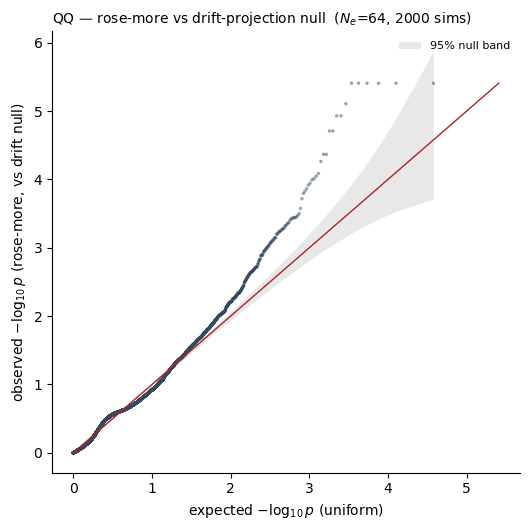

In [5]:
# --- QQ: observed rose-more residuals vs the drift-projection null (guarded blocks) ---
gg = d[d.guard==True]
pv = np.sort(gg.p_pos_marg.values); mm = len(pv)
exp = -np.log10((np.arange(1,mm+1)-0.5)/mm); obs = -np.log10(np.clip(pv,1e-300,1))
from scipy.stats import beta as _beta
_i=np.arange(1,mm+1); _lo=_beta.ppf(0.025,_i,mm-_i+1); _hi=_beta.ppf(0.975,_i,mm-_i+1)
fig, ax = plt.subplots(figsize=(5.4,5.4))
ax.fill_between(exp, -np.log10(np.clip(_hi,1e-300,1)), -np.log10(np.clip(_lo,1e-300,1)),
                color="grey", alpha=.18, lw=0, label="95% null band")
ax.scatter(exp, obs, s=6, c="#34495e", alpha=.5, edgecolors="none")
lim=max(exp.max(),obs.max()); ax.plot([0,lim],[0,lim], color="firebrick", lw=1)
ax.set_xlabel(r"expected $-\log_{10}p$ (uniform)"); ax.set_ylabel(r"observed $-\log_{10}p$ (rose-more, vs drift null)")
ax.set_title(f"QQ — rose-more vs drift-projection null  ($N_e$={dnm['Ne']:.0f}, {dnm['NSIM']} sims)", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Genes in the rose-more-than-ecotype blocks

Genes overlapping the **boundary-guarded, drift-null-significant** rose-more haploblocks (the alleles
that rose more than linkage to the winning founders predicts), annotated from **Ensembl Plants**
(TAIR10), precomputed so the notebook stays load-only. ★ marks genome-wide FWER-significant blocks.

In [6]:
# --- precomputed Ensembl-Plants annotation of the rose-more significant blocks ---
gt = pd.read_csv(f"{H}/site{SITE}_linear_rosemore_genes.csv")
gt["region"] = gt.chrom + ":" + gt.start.astype(str) + "-" + gt.end.astype(str)
n_sig=len(gt); n_fwer=int((gt.fwer=="★").sum()); n_with=int((gt.n_genes>0).sum())
print(f"SUMMARY — site {SITE}, linear-scale rose-more block-specific selection")
print(f"  {n_sig} drift-null-significant (q<0.05) rose-more blocks; {n_fwer} genome-wide FWER (★)")
print(f"  {n_with}/{n_sig} overlap >=1 annotated gene; {int(gt.n_genes.sum())} gene-overlaps total")
# clusteredness: contiguous blocks on the same chromosome
gt2 = gt.sort_values(["chrom","start"])
print("  significant blocks by chromosome:", dict(gt.chrom.value_counts().sort_index()))
gt[["fwer","region","panel_freq","s","linked_bg","resid","z","q_pos_drift","n_genes","symbols","gene_descriptions"]].rename(
    columns={"gene_descriptions":"genes (symbol: Ensembl description)"})

SUMMARY — site 4, linear-scale rose-more block-specific selection
  11 drift-null-significant (q<0.05) rose-more blocks; 4 genome-wide FWER (★)
  9/11 overlap >=1 annotated gene; 19 gene-overlaps total
  significant blocks by chromosome: {'Chr1': 2, 'Chr2': 7, 'Chr5': 2}


,fwer,region,panel_freq,s,linked_bg,resid,z,q_pos_drift,n_genes,symbols,genes (symbol: Ensembl description)
0,NaN,Chr5:22699397-22700803,0.27706,0.135504,0.074453,0.070964,4.206028,0.012325,0,NaN,NaN
1,★,Chr2:13770439-13775598,0.14719,0.078353,0.011915,0.076351,5.182766,0.012325,2,AT2G32430;KAO2,AT2G32430: Galactosyltransferase family protei...
2,★,Chr2:13767308-13770264,0.10823,0.093148,0.035660,0.067401,4.499789,0.012325,0,NaN,NaN
3,★,Chr2:13722496-13725256,0.22944,0.068622,-0.004002,0.082538,4.516042,0.012325,2,UCC1;AT2G32310,UCC1: uclacyanin 1; AT2G32310: CCT motif famil...
4,★,Chr2:13725657-13732568,0.10823,0.077794,0.014692,0.073015,4.548862,0.012325,4,AT2G32310;AT2G32315;AT2G32320;AT2G32340,AT2G32310: CCT motif family protein; AT2G32315...
5,NaN,Chr2:13820200-13822324,0.13853,0.080275,0.027444,0.062745,4.108061,0.012325,1,AT2G32550,"AT2G32550: Cell differentiation, Rcd1-like pro..."
6,NaN,Chr2:13813112-13815365,0.12554,0.079748,0.028043,0.061618,4.053254,0.021128,2,CSLB03;CSLB04,CSLB03: cellulose synthase-like B3; CSLB04: ce...
7,NaN,Chr2:13781101-13786054,0.20346,0.072166,0.019574,0.062506,3.968507,0.024650,2,AT2G32450;MYB101,AT2G32450: Calcium-binding tetratricopeptide f...
8,NaN,Chr1:1471322-1476752,0.34632,0.171418,0.118275,0.063057,3.913891,0.024650,1,AT1G05120,AT1G05120: Helicase protein with RING/U-box do...
9,NaN,Chr1:2984916-2988629,0.23377,0.183637,0.135780,0.057771,3.846711,0.033613,4,NAS3;AT1G09245;AT1G04687;AT1G04693,NAS3: nicotianamine synthase 3; AT1G09245: Pla...
